In [2]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [4]:
X

array([[-6.23273312e-01,  3.39163952e-01],
       [-1.02891522e-01, -7.28263924e-01],
       [ 1.92794840e+00, -7.11034957e-01],
       [ 8.63257679e-01, -5.54394198e-01],
       [ 2.46442019e-01, -6.53073398e-01],
       [-1.33473110e+00,  4.18343548e-01],
       [-3.16612019e-01,  6.16116471e-01],
       [-2.82673879e-01, -8.25814881e-01],
       [ 6.22785742e-01,  7.44664000e-01],
       [ 5.08709180e-02, -9.21206250e-02],
       [ 7.80082376e-01,  3.13187219e-01],
       [-2.75918302e-01, -8.26454353e-01],
       [-1.33390103e-01, -5.03892586e-01],
       [-3.65214841e-02, -1.05659450e+00],
       [ 1.23188261e+00, -2.35366618e+00],
       [ 5.12496001e-01,  9.03788007e-03],
       [ 9.98040752e-01, -1.60264085e+00],
       [-1.00636716e-01, -4.81023022e-01],
       [-8.92410921e-01, -5.21816726e-01],
       [-7.93977898e-01, -1.08464266e+00],
       [ 3.75627665e-01, -1.55489782e-02],
       [-1.73269990e-01,  7.14792135e-01],
       [-4.97923192e-01,  6.04978820e-01],
       [-5.

In [5]:
y

array([  25.05304991,  -89.99429029,  207.97087009,   42.80971182,
         57.78819418, -149.30659734,   13.50766169, -148.83022168,
         48.58483098,  -47.76524696,  105.08753854,  -69.25561942,
        -24.41261697, -159.10052326,  -23.55278856,  -69.31665613,
          0.58990197,   40.89216731,  -70.78272488,  -85.96774709,
         49.04690565,   80.52632721,  -52.41997524,    1.38979345,
         -8.74103249,   13.30078137,   -7.92110428,  -85.0740693 ,
       -181.5745148 ,   35.67453197,  122.29220651,   31.26721415,
         60.62758279, -167.82159672,  139.84084703, -154.92703361,
        -97.91744676, -104.6534584 ,  123.59961313,   80.69724939,
        148.23038138, -138.13902093,  -34.72867482,    1.78061378,
        -57.43504734, -132.50963075,  -35.57559331,  -72.2254714 ,
          9.99526894,  -52.85878414,  152.26029722,   83.07894179,
       -157.86342905,  224.36491767,   11.29904867,   27.00258491,
         45.08497392,   69.47078474,   19.73153859,   38.68521

In [6]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [7]:
df

,feature1,feature2,target
0,-0.623273,0.339164,25.053050
1,-0.102892,-0.728264,-89.994290
2,1.927948,-0.711035,207.970870
3,0.863258,-0.554394,42.809712
4,0.246442,-0.653073,57.788194
...,...,...,...
95,-0.636293,0.811932,-57.867171
96,-0.134327,-0.098852,33.135830
97,-0.805906,0.526815,-81.527439
98,0.440861,0.324095,54.610798


In [8]:
df.shape

(100, 3)

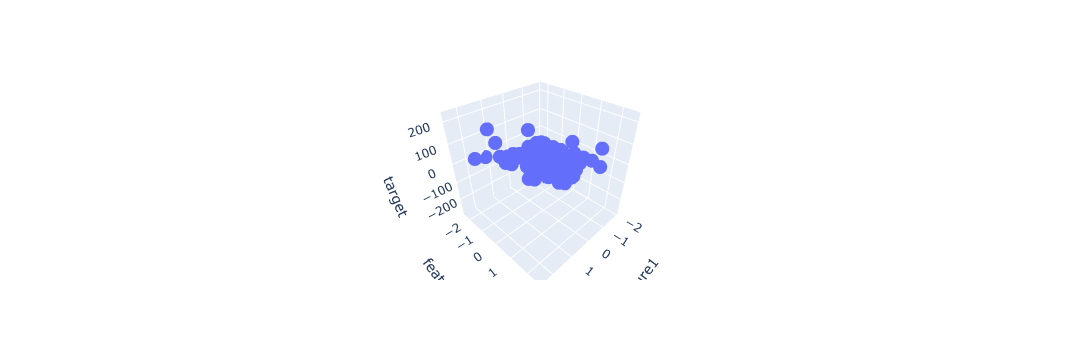

In [10]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()     

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test)

In [16]:
y_pred

array([ -79.69654856,   -2.61998552,    6.25534704,  -32.20761244,
        -20.09701811,  -85.23014655,   56.38390283,   -5.49509659,
         56.73724955,   43.99674396,   40.38704743,   -3.1853214 ,
        130.85279519,  -42.68695272,  104.44392229, -148.4587514 ,
          9.91659451,  -29.08576776,   22.82948229, -161.67429216])

In [17]:
y_test

array([ -69.91463123,  -67.89761965,   13.50766169,   -5.65293672,
         33.13583048,  -72.88543083,   54.61079849,  -34.72867482,
         13.30078137,  -69.31665613,   79.74889993,  -47.76524696,
        164.01826391,  -81.52743854,  139.84084703, -200.18755541,
         24.72422463,    1.38979345,   38.68521419, -132.50963075])

In [19]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 34.77888514760735
MSE 1800.4602808522475
R2 score 0.7505852899673633


In [25]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack(
    (xGrid.ravel().reshape(1, 100),
     yGrid.ravel().reshape(1, 100))
).T

z_final = lr.predict(final).reshape(10, 10)

z = z_final

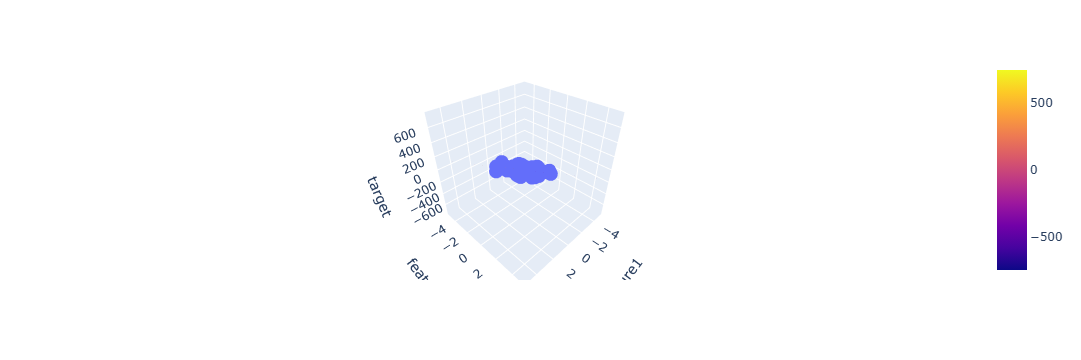

In [27]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.add_trace(go.Surface(x = x, y = y, z =z ))
fig.show()

In [29]:
lr.coef_

array([89.15087609, 59.58752299])

In [30]:
lr.intercept_

-2.231268447459497